In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Step 1: Four Models

In [3]:
WINDOW = 750   
CONF = 0.99    

MODELS = {
    'Historical': (r'C:\Users\sentr\Downloads\Internships\QFI\CSV Files\historical_simulation_var_es.csv', ''),
    'EWMA':       (r'C:\Users\sentr\Downloads\Internships\QFI\CSV Files\ewma_scaled_var_es.csv',           'EWMA_'),
    'GARCH':      (r'C:\Users\sentr\Downloads\Internships\QFI\CSV Files\garch_scaled_var_es.csv',          'GARCH_'),
    'GJR-GARCH':  (r'C:\Users\sentr\Downloads\Internships\QFI\CSV Files\gjr_garch_scaled_var_es.csv',      'GJR_'),
}


COLORS = {'Historical': 'grey', 'EWMA': 'green', 'GARCH': 'blue', 'GJR-GARCH': 'red'}

In [4]:
data = {name: pd.read_csv(f, index_col=0, parse_dates=True) for name, (f, _) in MODELS.items()}

common = None
for df in data.values():
    common = df.index if common is None else common.intersection(df.index)
data = {name: df.loc[common] for name, df in data.items()}
print(f"Comparing the models over {len(common)} common days ({common.min().date()} to {common.max().date()})")

Comparing the models over 755 common days (2023-07-21 to 2026-07-24)


In [5]:
# Step 2: Average VaR, VaR volatility and average ES for each model
tag = f"{WINDOW}d_{CONF * 100}%"       

rows = []
for name, (_, prefix) in MODELS.items():
    var_pct = data[name][f"{prefix}VaR_pct_{tag}"] * 100     # VaR as % of portfolio
    es_pct = data[name][f"{prefix}ES_pct_{tag}"] * 100       # Expected Shortfall as % of portfolio
    rows.append({'Model': name,
                 'Avg_VaR_%': var_pct.mean(),
                 'VaR_Volatility_%': var_pct.std(),          # how much the VaR number moves around
                 'Avg_ES_%': es_pct.mean()})
table = pd.DataFrame(rows).set_index('Model')
assert (table['Avg_ES_%'] >= table['Avg_VaR_%']).all(), "Average ES should never be below average VaR."

In [6]:
# Step 3: Adding the backtest results already computed in Phase 8
bt_all = pd.read_csv('backtest_summary.csv')
bt = bt_all[(bt_all['Window'] == WINDOW) & np.isclose(bt_all['Confidence'], CONF)].set_index('Model')
assert int(bt['Obs'].iloc[0]) == len(common), "Phase 8 used a different set of days - re-run Phases 4-8 together."

table = table.join(bt[['Exceptions', 'Expected_Exceptions', 'Exception_Ratio',
                       'Kupiec_p', 'CC_p', 'Basel_Last250_Zone', 'Result']])

In [7]:
# Step 4: Rank the models with three simple rules
#   1) A model that PASSED the Phase 8 backtest beats one that failed
#   2) Then the exception ratio closest to 1.0 wins (the model did what it promised)
#   3) If still tied, the lower average VaR wins (less capital tied up)
# -----------------------------------------------------------------
table['Distance_From_1'] = (table['Exception_Ratio'] - 1).abs()
table['Failed'] = table['Result'] != 'PASS'
table = table.sort_values(['Failed', 'Distance_From_1', 'Avg_VaR_%'])
table.insert(0, 'Rank', range(1, len(table) + 1))

worst_loss = -data['Historical']['Daily_PnL'].min()
print(f"\nWorst single-day loss in this period: ${worst_loss:,.0f} (the same for every model)")

print(f"\n=== Model comparison: {CONF:.1%} VaR, {WINDOW}-day window ===")
show = ['Rank', 'Exceptions', 'Expected_Exceptions', 'Exception_Ratio', 'Avg_VaR_%',
        'VaR_Volatility_%', 'Avg_ES_%', 'Kupiec_p', 'CC_p', 'Basel_Last250_Zone', 'Result']
print(table[show].round(3).to_string())

print("\n=== Passes across ALL 9 window/confidence combinations (from Phase 8) ===")
print(bt_all.groupby('Model')['Result'].apply(lambda s: f"{(s == 'PASS').sum()} of {len(s)}").to_string())

table[show].to_csv('model_comparison_simple.csv')
print("\nSaved: model_comparison_simple.csv")


Worst single-day loss in this period: $122,043 (the same for every model)

=== Model comparison: 99.0% VaR, 750-day window ===
            Rank  Exceptions  Expected_Exceptions  Exception_Ratio  Avg_VaR_%  VaR_Volatility_%  Avg_ES_%  Kupiec_p   CC_p Basel_Last250_Zone Result
Model                                                                                                                                               
GJR-GARCH      1           8                 7.55            1.060      2.397             0.771     2.917     0.871  0.906              Green   PASS
EWMA           2           7                 7.55            0.927      2.353             0.842     3.111     0.839  0.142              Green   PASS
GARCH          3           7                 7.55            0.927      2.411             0.716     2.947     0.839  0.142              Green   PASS
Historical     4           7                 7.55            0.927      2.884             0.406     3.649     0.839  0.142     

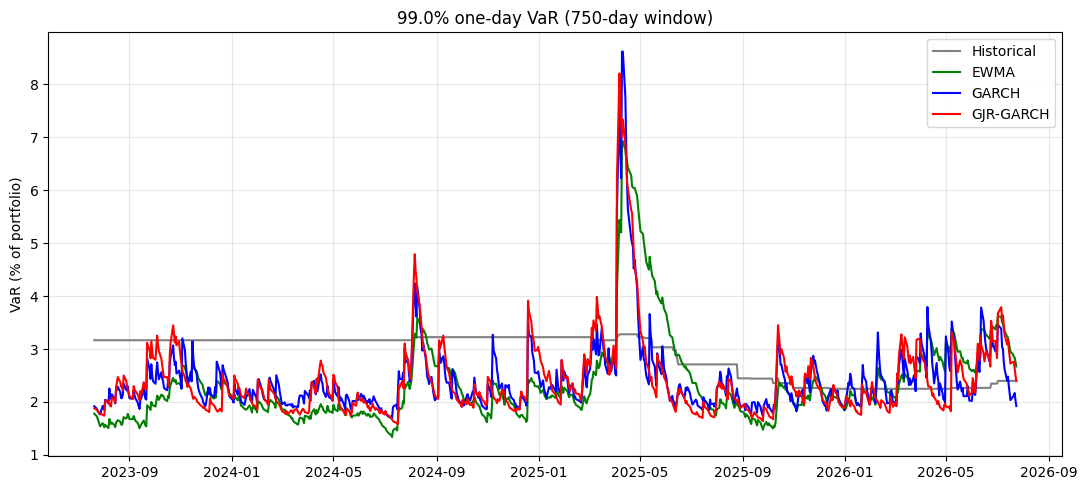

In [8]:
# Chart 1: the four VaR lines together
fig, ax = plt.subplots(figsize=(11, 5))
for name, (_, prefix) in MODELS.items():
    ax.plot(common, data[name][f"{prefix}VaR_pct_{tag}"] * 100, label=name, color=COLORS[name])
ax.set_title(f"{CONF:.1%} one-day VaR ({WINDOW}-day window)")
ax.set_ylabel("VaR (% of portfolio)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('simple_chart1_var_lines.png', dpi=130)
plt.show()

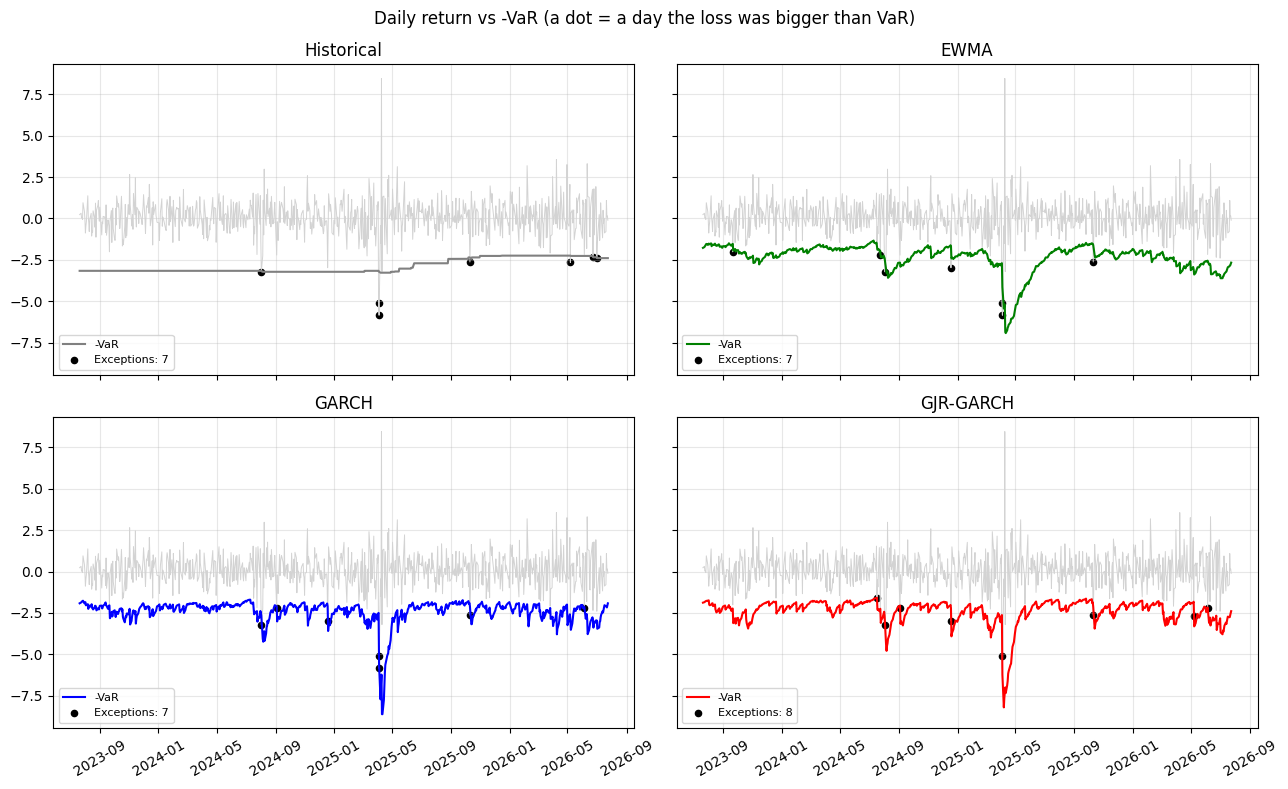

In [9]:
# Chart 2: actual daily return vs -VaR, exceptions marked as dots
ret_pct = data['Historical']['Daily_PnL'] / data['Historical']['Portfolio_Dollar_Value_Prior'] * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, (name, (_, prefix)) in zip(axes.ravel(), MODELS.items()):
    var_pct = data[name][f"{prefix}VaR_pct_{tag}"] * 100
    exception = (-ret_pct) > var_pct                       # True on days the loss beat VaR
    ax.plot(common, ret_pct, color='lightgrey', linewidth=0.7)
    ax.plot(common, -var_pct, color=COLORS[name], label='-VaR')
    ax.scatter(common[exception.values], ret_pct[exception.values], color='black', s=20,
               label=f"Exceptions: {int(exception.sum())}")
    ax.set_title(name)
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.3)
for ax in axes[1]:
    ax.tick_params(axis='x', rotation=30)
fig.suptitle("Daily return vs -VaR (a dot = a day the loss was bigger than VaR)")
fig.tight_layout()
fig.savefig('simple_chart2_return_vs_var.png', dpi=130)
plt.show()

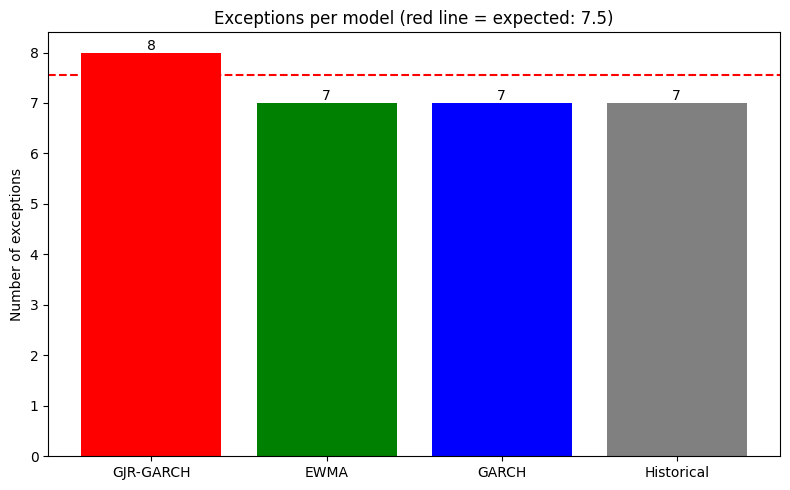

In [10]:
# Chart 3: number of exceptions per model, against the number expected
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(table.index, table['Exceptions'], color=[COLORS[m] for m in table.index])
ax.bar_label(bars)
expected = table['Expected_Exceptions'].iloc[0]
ax.axhline(expected, color='red', linestyle='--')
ax.set_title(f"Exceptions per model (red line = expected: {expected:.1f})")
ax.set_ylabel("Number of exceptions")
fig.tight_layout()
fig.savefig('simple_chart3_exceptions.png', dpi=130)
plt.show()